# Validation subset creation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path
from typing import Any, Dict

# Add parent directory to path to import from src
sys.path.append("..")
# Import SAR utilities
from src.utils.sar_utils import (
    convert_to_db,
    load_cosar,
    symmetrize,
    preserve_point_like_scatterers,
    normalize_ndarray,
)

# Hyperparameters
SHORT_IMAGE_NAME = "Hamburg"
CROP_COORDINATES = (11000, 8500)  # Hamburg: ncolumns=14686 nlines=32901
PATCH_SIZE = (1024, 1024)
DATASET_SPEC = "randomsplit2im_pres60_norm5nat"

# Paths
COSFILES_DIR = Path("../data/TSX_cos_files")
PROCESSED_DIR = Path("../data/processed_hdf5")

test

In [2]:
def find_image(image_name: str) -> Path:
    """Return the path to the image that starts with image_name in COSFILES_DIR"""
    for file in COSFILES_DIR.iterdir():
        if file.name.startswith(image_name):
            return file
    raise FileNotFoundError(
        f"No file starting with {image_name} found in {COSFILES_DIR}"
    )


def parse_specifications_from_dataset_name(dataset_name: str) -> Dict[str, Any]:
    splits = dataset_name.split("_")
    # splits[0] has no info
    # splits[1] is "pres" + the preservation threshold in dB
    # splits[2] is "norm" + the percentile + log base + if clipping was used

    if splits[1].startswith("pres"):
        preservation_threshold = int(splits[1][4:])
    else:
        preservation_threshold = None

    normalization = splits[2][4:]
    if normalization.endswith("clip"):
        normalization = normalization[:-4]
        clipping = True
    else:
        clipping = False

    if normalization.endswith("nat"):
        normalization = normalization[:-3]
        log_base = "nat"
    elif normalization.endswith("db"):
        normalization = normalization[:-2]
        log_base = "db"
    else:
        normalization = None

    percentile = int(normalization)

    return {
        "preservation_threshold": preservation_threshold,
        "percentiles": (percentile, 100 - percentile),
        "log_base": log_base,
        "clipping": clipping,
    }


def compute_statistics(data):
    return {
        "min": np.min(data),
        "p1": np.percentile(data, 1),
        "p10": np.percentile(data, 10),
        "mean": np.mean(data),
        "median": np.median(data),
        "std": np.std(data),
        "p90": np.percentile(data, 90),
        "p99": np.percentile(data, 99),
        "max": np.max(data),
    }


def print_statistics(data, name):
    stats = compute_statistics(data)
    print(f"Statistics for {name}:")
    for key, value in stats.items():
        print(f" - {key}: {value:.4f}")
    print("\n")


## Create the patch
1. Load the image
2. Crop the area of interest using 2 hyperparameters: tuple with start location and tuple with patch size
3. TSX preprocessing pipeline:
   1. Symmetrize
   2. Square
   3. Preserve strong scatterers
   4. Normalize
4. Store patch as a numpy array in the corresponding dataset

In [ ]:
# Setup
image_path = find_image(SHORT_IMAGE_NAME)
print(image_path)
specs = parse_specifications_from_dataset_name(DATASET_SPEC)
print(specs)

# Load
image_np = load_cosar(image_path, verbose=True)
if image_np is None:
    raise ValueError(f"Image {image_path} could not be loaded")

# Crop
original_patch_np = image_np[
    CROP_COORDINATES[0] : CROP_COORDINATES[0] + PATCH_SIZE[0],
    CROP_COORDINATES[1] : CROP_COORDINATES[1] + PATCH_SIZE[1],
    :,
]

# Pre-process
patch_np = symmetrize(original_patch_np)
patch_np = np.square(patch_np)
if specs["preservation_threshold"] is not None:
    patch_np, _ = preserve_point_like_scatterers(
        patch_np, specs["preservation_threshold"]
    )
if specs["log_base"] is not None:
    patch_np = normalize_ndarray(
        patch_np,
        specs["log_base"],
        specs["percentiles"],
        specs["clipping"],
    )

# Store
patch_path = (
    PROCESSED_DIR
    / DATASET_SPEC
    / f"val_{SHORT_IMAGE_NAME}_{PATCH_SIZE[0]}x{PATCH_SIZE[1]}.npy"
)
np.save(patch_path, patch_np)

../data/TSX_cos_files/Hamburg_TDX1_SAR__SSC______SM_S_SRA_20180112T165337_20180112T165345_IMAGE_HH_SRA_strip_004.cos
{'preservation_threshold': 60, 'percentiles': (5, 95), 'log_base': 'nat', 'clipping': False}
                Reading image in CoSAR format. ncolumns=14686 nlines=32901
                Successfully loaded image with shape: (32901, 14686) ([:,:,0] real and [:,:,1] imaginary).
Using percentiles: (5, 95) with values 6.76272625759834, 11.667549457990336


## Load and visualize the patch

Statistics for Patch:
 - min: -8.7274
 - p1: -1.2577
 - p10: -0.3177
 - mean: 0.3127
 - median: 0.3667
 - std: 0.5118
 - p90: 0.8986
 - p99: 1.2652
 - max: 1.4378




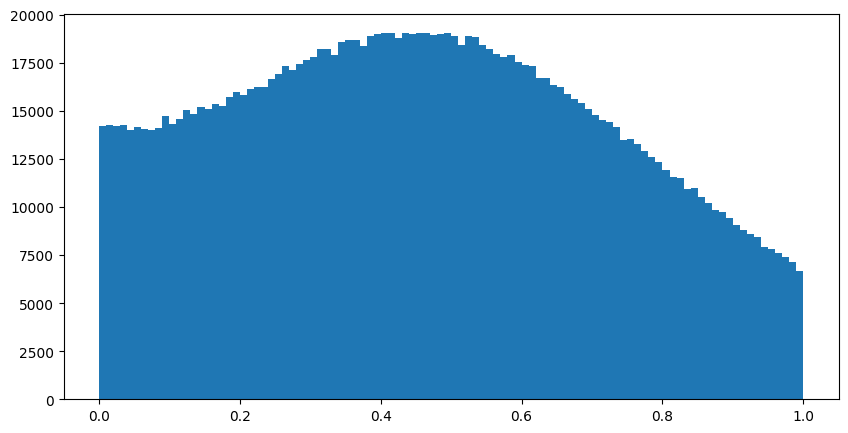

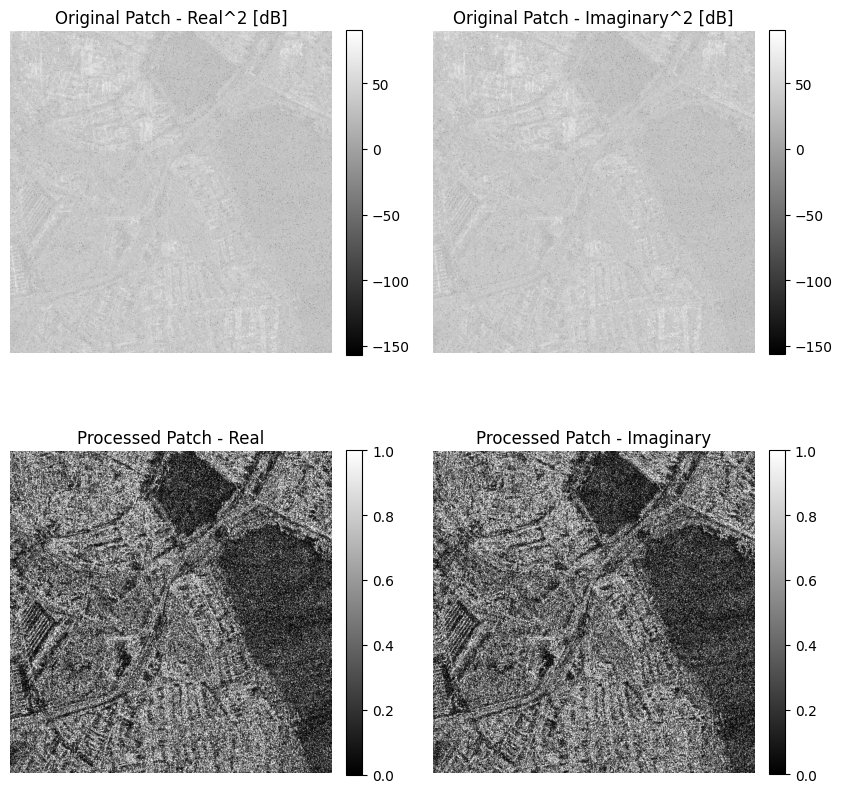

In [4]:
# Load the patch
patch_np = np.load(patch_path)
print_statistics(patch_np, "Patch")
# plot histogram
plt.figure(figsize=(10, 5))
plt.hist(
    patch_np.flatten(),
    bins=100,
    range=(0, 1),
)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
im0 = axs[0, 0].imshow(convert_to_db(original_patch_np[:, :, 0] ** 2), cmap="gray")
im1 = axs[0, 1].imshow(convert_to_db(original_patch_np[:, :, 1] ** 2), cmap="gray")
im2 = axs[1, 0].imshow(patch_np[:, :, 0], cmap="gray", vmin=0, vmax=1)
im3 = axs[1, 1].imshow(patch_np[:, :, 1], cmap="gray", vmin=0, vmax=1)
axs[0, 0].set_title("Original Patch - Real^2 [dB]")
axs[0, 1].set_title("Original Patch - Imaginary^2 [dB]")
axs[1, 0].set_title("Processed Patch - Real")
axs[1, 1].set_title("Processed Patch - Imaginary")
# Add colorbars
fig.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axs[1, 0], fraction=0.046, pad=0.04)
fig.colorbar(im3, ax=axs[1, 1], fraction=0.046, pad=0.04)
# turn off axis
for ax in axs.flat:
    ax.axis("off")